In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df=pd.read_csv(r"E:\panda\IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

1.Cleaning


->lowercasing


->removing leading and trailing spaces


->remove html tags


->Expanding abbreviations


->spelling correction


->punctuation


->remove special character

2.Preprocessing

3.EDA

4.MAke feature

5.vectorization

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.duplicated().sum()

np.int64(418)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#cleaning 
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
df['review']=df['review'].str.lower()

In [14]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [16]:
#remove white space
df['review']=df['review'].str.strip()

In [17]:
#remove html tag
import re

def remove_html(data):
    clean = re.sub(r'<.*?>', '', data)
    return clean


In [18]:
remove_html('<p>my name is showmik</p>')

'my name is showmik'

In [19]:
df['review'].apply(remove_html)

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 49582, dtype: object

In [22]:
df['review']=df['review'].str.replace(r'<.*?>', '')

In [25]:
#remove url
df['review'] = df['review'].str.replace(r'https?://\S+|www\.\S+', '', regex=True)


In [26]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [28]:
import re

def remove_abb(data):
    # Use: re.sub(pattern, replacement, string)
    data = re.sub(r"\bhe's\b", "he is", data, flags=re.IGNORECASE)
    data = re.sub(r"\bshe's\b", "she is", data, flags=re.IGNORECASE)
    data = re.sub(r"\bi'm\b", "i am", data, flags=re.IGNORECASE)
    data = re.sub(r"\bcan't\b", "cannot", data, flags=re.IGNORECASE)
    data = re.sub(r"\bdon't\b", "do not", data, flags=re.IGNORECASE)
    data = re.sub(r"\bwon't\b", "will not", data, flags=re.IGNORECASE)
    data = re.sub(r"\bit's\b", "it is", data, flags=re.IGNORECASE)
    data = re.sub(r"\bthey're\b", "they are", data, flags=re.IGNORECASE)
    data = re.sub(r"\byou're\b", "you are", data, flags=re.IGNORECASE)
    data = re.sub(r"\bi've\b", "i have", data, flags=re.IGNORECASE)
    data = re.sub(r"\bdoesn't\b", "does not", data, flags=re.IGNORECASE)
    return data

In [29]:
remove_abb("he's a doctor")

'he is a doctor'

In [31]:
df['review']=df['review'].apply(remove_abb)

In [32]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [36]:
from textblob import TextBlob

In [37]:
def spelling_cor(text):
    return TextBlob(text).correct().string

In [42]:
spelling_cor("i am goi to the markt")

'i am go to the market'

In [43]:
df['review']=df['review'].apply(spelling_cor)

KeyboardInterrupt: 

In [47]:
#punction
import string

In [49]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [52]:
import string

def remove_pun(text):
    for i in string.punctuation:
        if i in text: # This is your "contains" check
            text = text.replace(i, '')
    return text

In [53]:
remove_pun(" !hello, how are you?")

' hello how are you'

In [54]:
df['review']=df['review'].apply(remove_pun)

In [55]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


processing

In [56]:
#tokenize
from nltk.tokenize import word_tokenize

In [57]:
df['tokenized_reviw']=df['review'].apply(word_tokenize) 

In [58]:
df.head()

,review,sentiment,tokenized_reviw
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production br br the filmin...,positive,"[a, wonderful, little, production, br, br, the..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically theres a family where a little boy j...,negative,"[basically, theres, a, family, where, a, littl..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon..."


In [59]:
#stop word removal
from nltk.corpus import stopwords

In [60]:
stopwords.words('english')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [61]:
len(stopwords.words('english'))

179

In [70]:
import nltk
from nltk.corpus import stopwords

# 1. Do this ONCE outside the function
nltk.download('stopwords')
stop_words = set(stopwords.words('english')) 

def remove_stop(text):
    # 2. Ensure 'text' is a list of words, not a string of characters
    if isinstance(text, str):
        text = text.split()
        
    # 3. Use a list comprehension (much faster than .append)
    return [word for word in text if word.lower() not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [71]:
df['tokenized_reviw']= df['tokenized_reviw'].apply(remove_stop)

In [72]:
df.head()

,review,sentiment,tokenized_reviw
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production br br the filmin...,positive,"[wonderful, little, production, br, br, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically theres a family where a little boy j...,negative,"[basically, theres, family, little, boy, jake,..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,..."


EDA

In [74]:
df['review']=df['tokenized_reviw'].apply(lambda x:" ".join(x))

In [75]:
df.head()

,review,sentiment,tokenized_reviw
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,wonderful little production br br filming tech...,positive,"[wonderful, little, production, br, br, filmin..."
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically theres family little boy jake thinks...,negative,"[basically, theres, family, little, boy, jake,..."
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,..."


add feature

In [77]:
df['char lenght']=df['review'].str.len()

In [78]:
df.head()

,review,sentiment,tokenized_reviw,char lenght
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1161
1,wonderful little production br br filming tech...,positive,"[wonderful, little, production, br, br, filmin...",674
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",587
3,basically theres family little boy jake thinks...,negative,"[basically, theres, family, little, boy, jake,...",467
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",876


In [79]:
df['word_lenght']=df['tokenized_reviw'].apply(len)

In [80]:
df.head()

,review,sentiment,tokenized_reviw,char lenght,word_lenght
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1161,170
1,wonderful little production br br filming tech...,positive,"[wonderful, little, production, br, br, filmin...",674,90
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",587,87
3,basically theres family little boy jake thinks...,negative,"[basically, theres, family, little, boy, jake,...",467,71
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",876,130


In [81]:
import seaborn as sns

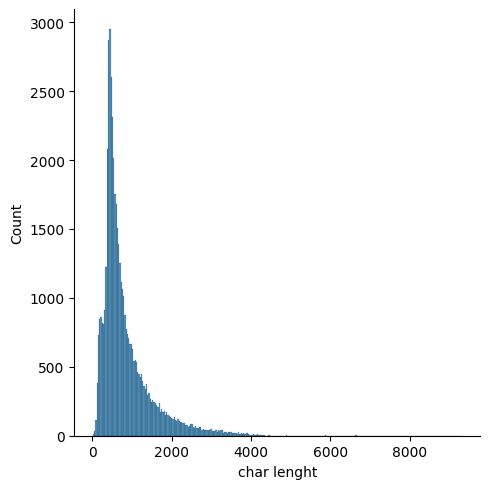

In [82]:
sns.displot(df['char lenght'])

In [83]:
df[df['sentiment']=='positive']

,review,sentiment,tokenized_reviw,char lenght,word_lenght
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1161,170
1,wonderful little production br br filming tech...,positive,"[wonderful, little, production, br, br, filmin...",674,90
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",587,87
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",876,130
5,probably alltime favorite movie story selfless...,positive,"[probably, alltime, favorite, movie, story, se...",400,58
...,...,...,...,...,...
49983,loved fan original series always wondered back...,positive,"[loved, fan, original, series, always, wondere...",434,65
49985,imaginary heroes clearly best film year comple...,positive,"[imaginary, heroes, clearly, best, film, year,...",717,106
49989,got one weeks ago love modern light filled tru...,positive,"[got, one, weeks, ago, love, modern, light, fi...",603,88
49992,john garfield plays marine blinded grenade fig...,positive,"[john, garfield, plays, marine, blinded, grena...",638,88


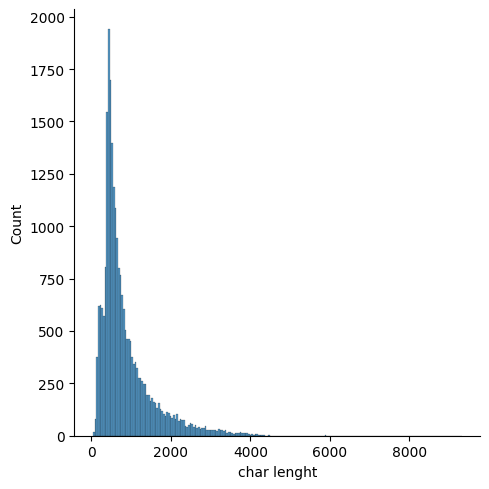

In [86]:
sns.displot(df[df['sentiment']=='positive']['char lenght'])

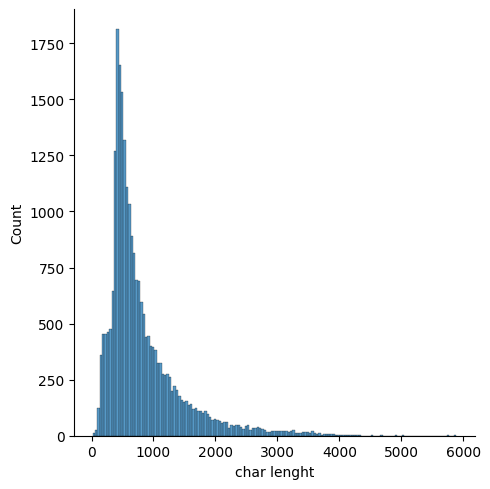

In [87]:
sns.displot(df[df['sentiment']=='negative']['char lenght'])

In [96]:
from nltk import ngrams

vectorization

In [99]:
#bag of words
from sklearn.feature_extraction.text import CountVectorizer

In [101]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize
cv = CountVectorizer(max_features=5000)

# 2. Fit and Transform (Keep it as 'bag_of_words')
# DO NOT run .toarray() after this line
bag_of_words = cv.fit_transform(df['review']) 

# Now you can pass 'bag_of_words' directly into a model
# Example: model.fit(bag_of_words, y)

In [102]:
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3841161 stored elements and shape (49582, 5000)>